# Abandono Rural Study

Goal: explore rural abandonment with a narrative, framing, geography, time-shifted discourse, recovery signals, institutional fingerprints, and sector lenses.

In [9]:
from pathlib import Path
import pandas as pd
import re
import unicodedata
import spacy
import spacy.cli
import matplotlib.pyplot as plt

In [2]:
data_path = Path("clean_data/abandono_rural_clean.csv")
df = pd.read_csv(data_path)
df.head()

,query,original_url,archive_url,title,archive_date,year,archive_date_dt,snippet_clean,location_name,location_source,source_file
0,abandono rural,http://www.partido-socialista.pt/ps/programa/p...,https://arquivo.pt/wayback/19961013180606/http...,Economia e Desenvolvimento,845229966,1996,8452-02-09 09:06:06,"mundo rural estão em desagregação, já que se c...",desagregação,snippet_clean,abandono_rural_1996_C.csv
1,abandono rural,http://aurelia.si.fct.unl.pt/projects/www-amb/...,https://arquivo.pt/wayback/19961207092015/http...,pesperan,849950415,1996,NaN,"abandono da área rural e, simultaneamente, a d...",séc,snippet_clean,abandono_rural_1996_C.csv
2,abandono rural,http://www.partido-socialista.pt/ps/contrato/c...,https://arquivo.pt/wayback/19961013180612/http...,DESENVOLVIMENTO E EMPREGO,845229972,1996,8452-02-09 09:07:02,VIRAGEM: PRIORIDADES E COMPROMISSOS AS POLÍTIC...,últimos dez anos em,snippet_clean,abandono_rural_1996_C.csv
3,abandono rural,http://gabriel.mat.uc.pt/~cmf/artigos/horizont...,https://arquivo.pt/wayback/19961110032823/http...,Carlos Fonseca,847596503,1996,8475-09-06 05:00:03,"localidade rural de Hinojosa de Duero, na Prov...",Província de Salamanca,snippet_clean,abandono_rural_1996_C.csv
4,abandono rural,http://www.partido-socialista.pt/partido/bibli...,https://arquivo.pt/wayback/19970330181600/http...,Economia e Desenvolvimento,859745760,1997,8597-04-05 07:06:00,pique. A agricultura e o mundo rural estão em ...,desagregação,snippet_clean,abandono_rural_1997_C.csv


## 1) Narrativa e taxonomia das motivações de abandono
Classificamos automaticamente o texto em seis dimensões causais do abandono: demográfica, económica, infraestrutural, ambiental, cultural e serviços.

In [3]:
drivers = {
    "demographic": [
        "envelhecimento", "idosos", "despovoamento", "emigração", "emigracao",
        "migração", "migracao", "êxodo", "exodo", "baixa natalidade"
    ],
    "economic": [
        "emprego", "desemprego", "rendimentos", "pobreza", "salários",
        "salarios", "crise", "investimento", "indústria", "industria"
    ],
    "infrastructure": [
        "estradas", "transportes", "acessos", "internet", "mobilidade",
        "ferrovia", "rodovia", "ligações", "ligacoes", "comunicações"
    ],
    "services": [
        "saúde", "saude", "escola", "serviços", "servicos",
        "hospital", "urgências", "urgencias", "correios", "apoio social"
    ],
    "environment": [
        "incêndio", "incendio", "seca", "floresta", "desertificação",
        "desertificacao", "erosão", "erosao", "pragas", "cheias"
    ],
    "cultural": [
        "tradição", "tradicao", "património", "patrimonio", "identidade",
        "costumes", "festas", "associativismo", "herança", "heranca"
    ]
}
text = (
    df.get("title", "").fillna("").astype(str)
    + " "
    + df.get("snippet_clean", "").fillna("").astype(str)
 ).str.lower()
driver_counts = {
    k: text.str.contains("|".join(map(re.escape, v)), regex=True).sum()
    for k, v in drivers.items()
}
pd.Series(driver_counts).sort_values(ascending=False)

services          1004
environment        705
economic           589
demographic        508
cultural           307
infrastructure      88
dtype: int64

## 2) Media vs instituições
Comparamos como os media e as instituições que narram o abandono rural, evidenciando diferenças de prioridade e tom.

In [4]:
from urllib.parse import urlparse

df["domain"] = df.get("original_url", "").fillna("").map(
    lambda u: urlparse(u).netloc.lower()
 )

media_domains = ["publico.pt", "expresso.pt", "dn.pt", "lusa.pt", "jnoticias.pt"]
media_mask = df["domain"].str.contains("|".join(map(re.escape, media_domains)), na=False)

media_df = df[media_mask].copy()
inst_df = df[~media_mask].copy()

framing_counts = pd.DataFrame(
    {
        "group": ["media", "institutions"],
        "rows": [len(media_df), len(inst_df)],
    }
 )
framing_counts["share"] = (
    framing_counts["rows"] / framing_counts["rows"].sum()
 ).round(3)

top_media_domains = media_df["domain"].value_counts().head(10)

framing_counts, top_media_domains

(          group  rows  share
 0         media    91  0.015
 1  institutions  6088  0.985,
 domain
 www.publico.pt                  11
 jornal.publico.pt               11
 www.dn.pt                        8
 www.jnoticias.pt                 6
 ultimahora.publico.pt            4
 primeirasedicoes.expresso.pt     4
 ecosfera.publico.pt              4
 dossiers.publico.pt              4
 www.expresso.pt                  3
 semanal.expresso.pt              3
 Name: count, dtype: int64)

## 3) Geografias do abandono
Identificamos as localizações mais frequentemente mencionadas após filtragem ligeira, revelando os hotspots de preocupação territorial. Esta é uma funcionalidade que está ainda em desenvolvimento e esperamos implementar no futuro.

In [5]:
def normalize_text(text: str) -> str:
    s = "" if text is None else str(text)
    s = s.lower().strip()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    return s

try:
    nlp = spacy.load("pt_core_news_lg")
except OSError:
    try:
        spacy.cli.download("pt_core_news_sm")
        nlp = spacy.load("pt_core_news_sm")
    except OSError:
        spacy.cli.download("pt_core_news_lg")
        nlp = spacy.load("pt_core_news_lg")

nlp.max_length = 2_000_000

gazetteer = [
    "Norte", "Centro", "Lisboa", "Alentejo", "Algarve", "Acores", "Madeira",
"Beira Interior", "Beira Alta", "Beira Baixa", "Tras-os-Montes", "Douro",
"Alto Alentejo", "Baixo Alentejo", "Ribatejo",
"Aveiro", "Beja", "Braga", "Braganca", "Castelo Branco", "Coimbra",
"Evora", "Faro", "Guarda", "Leiria", "Lisboa", "Portalegre",
"Porto", "Santarem", "Setubal", "Viana do Castelo", "Vila Real", "Viseu",
"Covilha", "Fundao", "Seia", "Gouveia", "Manteigas", "Belmonte",
"Sabugal", "Pinhel", "Almeida", "Celorico da Beira", "Trancoso",
"Braganca", "Miranda do Douro", "Mirandela", "Chaves", "Mogadouro",
"Vimioso", "Vinhais", "Montalegre", "Boticas", "Valpacos",
"Vila Flor", "Alijo", "Peso da Regua", "Lamego", "Moimenta da Beira",
"Sernancelhe", "Tabuaco", "Armamar", "Tarouca", "Resende",
"Beja", "Serpa", "Moura", "Mertola", "Ourique", "Almodovar",
"Portalegre", "Elvas", "Ponte de Sor", "Avis", "Nisa", "Castelo de Vide",
"Moncao", "Melgaco", "Ponte da Barca", "Ponte de Lima", "Arcos de Valdevez"
]

gaz_norm = {normalize_text(p): p for p in gazetteer}

def ner_places(text: str) -> list[str]:
    if not text:
        return []
    doc = nlp(text)
    return [ent.text for ent in doc.ents if ent.label_ in {"LOC", "GPE"}]

def match_places(text: str) -> list[str]:
    if not text:
        return []
    found = set()
    norm = normalize_text(text)
    for gnorm, orig in gaz_norm.items():
        if gnorm and re.search(rf"\b{re.escape(gnorm)}\b", norm):
            found.add(orig)
    for ent in ner_places(text):
        ent_norm = normalize_text(ent)
        if ent_norm in gaz_norm:
            found.add(gaz_norm[ent_norm])
    return sorted(found)

df["locations_extracted"] = df.get("snippet_clean", "").fillna("").map(match_places)
locations_series = df["locations_extracted"].explode().dropna()
locations_series.value_counts().head(20)

✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


locations_extracted
Centro            149
Lisboa            107
Alentejo           86
Norte              85
Porto              60
Algarve            46
Tras-os-Montes     42
Douro              41
Madeira            37
Acores             33
Guarda             32
Beja               32
Evora              31
Almeida            29
Viseu              28
Chaves             24
Coimbra            20
Setubal            17
Vila Real          17
Braganca           17
Name: count, dtype: int64

## 4) Discurso temporal
Procurámos mudanças das motivações de abandono ano a ano entre 1996 e 2020, identificando tendências ao longo do tempo.

,demographic,economic,infrastructure,services,environment,cultural
year_num,,,,,,
1996,0,1,0,0,1,0
1997,3,2,0,2,1,0
1998,4,5,0,3,4,2
1999,0,4,0,7,6,3
2000,5,7,1,16,11,4
2001,13,21,1,30,16,8
2002,9,14,0,34,11,12
2003,15,18,0,34,18,14
2004,14,13,2,30,23,9


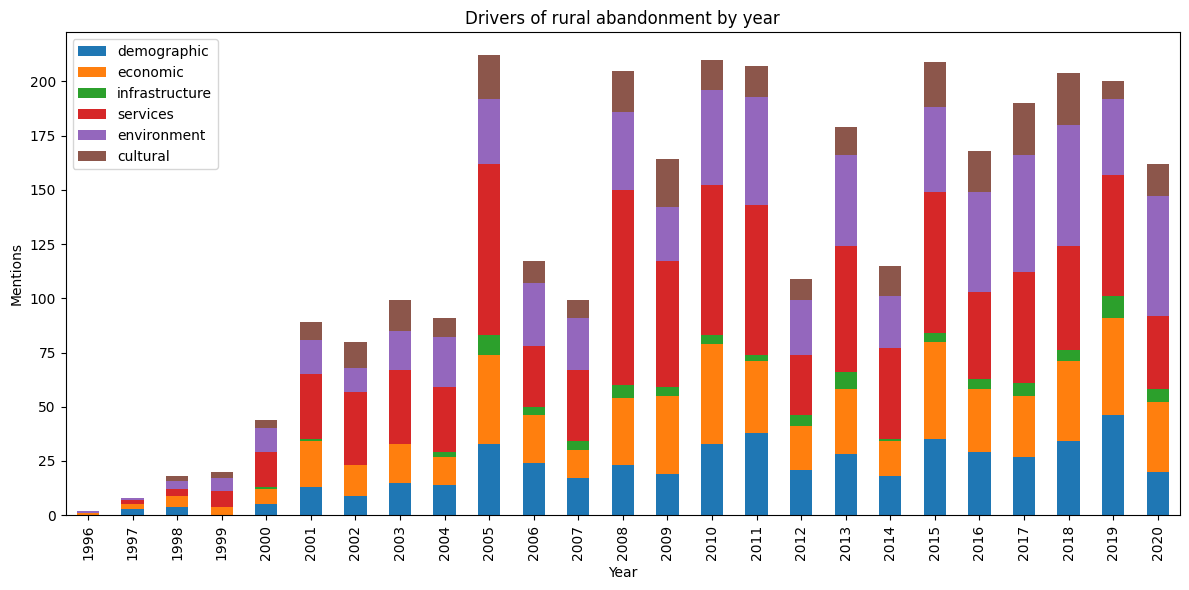

In [10]:
year_series = pd.to_numeric(df.get("year", pd.Series(dtype="object")), errors="coerce")
df_year = df.assign(year_num=year_series).dropna(subset=["year_num"])

text_year = (
    df_year.get("title", "").fillna("").astype(str)
    + " "
    + df_year.get("snippet_clean", "").fillna("").astype(str)
 ).str.lower()

driver_year_counts = {}
for driver, terms in drivers.items():
    hits = text_year.str.contains("|".join(map(re.escape, terms)), regex=True)
    driver_year_counts[driver] = (
        df_year.assign(hit=hits)
        .groupby("year_num")["hit"].sum()
)

driver_year_df = pd.DataFrame(driver_year_counts).fillna(0).sort_index()
driver_year_df = driver_year_df.astype(int)

driver_year_df.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Drivers of rural abandonment by year")
plt.xlabel("Year")
plt.ylabel("Mentions")
plt.tight_layout()

driver_year_df

## 5) Abandono vs reativação
Comparámos a linguagem de declínio e perda com a linguagem de recuperação, revitalização e oportunidades.

In [11]:
decline_terms = ["abandono", "despovoamento", "perda", "encerramento"]
revival_terms = ["reabilitação", "revitalização", "turismo", "reocupação", "reocupacao"]
decline_hits = text.str.contains("|".join(map(re.escape, decline_terms)), regex=True).sum()
revival_hits = text.str.contains("|".join(map(re.escape, revival_terms)), regex=True).sum()
decline_hits, revival_hits

(np.int64(5259), np.int64(740))

## 6) Domínios 
Identificámos quais os domínios (de sites governamentais, autarquias, media) que aparecem com mais frequência no debate.

In [12]:
df["domain"].value_counts().head(20)

domain
www.diramb.gov.pt          14
www.spea.pt                14
www.aps.pt                 13
www.agroportal.pt          12
www.ces.fe.uc.pt           12
www.icn.pt                 12
agroportal.pt              12
jornaldeangola.sapo.ao     12
www.publico.pt             11
www.gddc.pt                11
www.pcp.pt                 11
jornal.publico.pt          11
home.fa.utl.pt             11
www.ces.uc.pt              11
www.jornalnordeste.com     11
pt.wikipedia.org           11
www.iec.uminho.pt          10
www.parlamento.pt          10
casadalegiao.no.sapo.pt    10
www.agencia.ecclesia.pt    10
Name: count, dtype: int64

## 7) Divisão por setores
Classificámos os itens por setor (agricultura, turismo, indústria, serviços) para perceber quais as áreas mais associadas ao discurso de abandono.

In [14]:
sectors = {
    "agriculture": [
        "agricultura", "floresta", "agro", "agropecuaria", "pecuaria",
        "pastoricia", "pastoreio", "agricolas", "culturas", "vinha",
        "oliveira", "olival", "azeite", "gado", "sementes", "regadio", "sequeiro"
    ],
    "education": [
        "escola", "escolas", "universidade", "ensino", "alunos", "professores",
        "formacao", "formação", "infancia", "infância", "jardim de infancia",
        "secundario", "secundário", "politecnico", "politécnico"
    ],
    "health": [
        "saude", "saúde", "hospital", "centro de saude", "centro de saúde",
        "medico", "médico", "enfermagem", "urgencias", "urgências", "clinica", "clínica"
    ],
    "transport": [
        "estradas", "transportes", "comboio", "autocarro", "rodovia", "ferrovia",
"mobilidade", "acessos", "ligacoes", "ligações", "ponte", "viaduto"
    ],
    "tourism": [
        "turismo", "patrimonio", "património", "aldeias", "cultura", "museu",
        "museus", "gastronomia", "trilhos", "rotas", "natureza", "turistico", "turística"
    ],
    "housing": [
        "habitacao", "habitação", "imobiliario", "imobiliário", "casas", "ruinas",
"ruínas", "habitado", "vazio", "reabilitacao", "reabilitação", "arrendamento"
    ]
}
sector_counts = {
    k: text.str.contains("|".join(map(re.escape, v)), regex=True).sum()
    for k, v in sectors.items()
}
pd.Series(sector_counts).sort_values(ascending=False)

tourism        1967
agriculture    1369
education      1123
housing         289
health          131
transport       118
dtype: int64